# Phase 3 — Continuous Decoding · DANDI_000688 (S3)

Predicts hand velocity (vx, vy) from binned spike counts using Ridge, Wiener filter,
and Kalman filter on DANDI_000688 (~54 electrodes, vx ≠ vy confirmed).

| Cell | Content |
|------|---------|
| 1 | Imports + AWS credentials |
| 2 | S3 connection + session load (DANDI_000688) |
| 3 | Feature extraction: binned spikes + velocity → per-trial chunks via `get_trial_data` |
| 4 | Trial-boundary 80/20 train/test split |
| 5 | Ridge decoder |
| 6 | Wiener filter decoder |
| 7 | Kalman filter decoder |
| 8 | Summary table |
| 9 | Predicted vs actual velocity plots |

**Prerequisites:** AWS credentials for the `cv-pc` profile must be present in
`~/.aws/credentials`. If the S3 connection fails, set up credentials with
`aws configure --profile cv-pc` or copy the key/secret from the lab's shared
credentials file before running Cell 2.

In [1]:
from pathlib import Path
from sklearn.decomposition import PCA
import sys
_repo_root = Path.cwd() if (Path.cwd() / "decoding").is_dir() else Path.cwd().parent
if str(_repo_root) not in sys.path:
    sys.path.insert(0, str(_repo_root))

import os
import configparser
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from bci_decoding_dataset import DatasetLoader

from decoding import (
    compute_bin_phases,
    compute_binned_counts,
    compute_binned_trial_ids,
    DimReducer,
    KalmanFilterDecoder,
    RidgeDecoder,
    WienerFilterDecoder,
    WienerRidgeDecoder,
)

sns.set_theme(style="whitegrid", font_scale=1.1)
warnings.filterwarnings("ignore", category=PendingDeprecationWarning)

# ── Pipeline parameters (only values that may need tuning) ──────────────────
BIN_SIZE_MS = 50    # spike binning window (ms)
N_LAGS      = 10     # Wiener filter: past bins appended as features
TRAIN_FRAC  = 0.80  # temporal train/test split
PLOT_BINS   = 200   # bins shown in trace plots

# ── AWS credentials from ~/.aws/credentials ─────────────────────────────────
#credentials_path = os.path.expanduser("~/.aws/credentials")
#config = configparser.ConfigParser()
#config.read(credentials_path)
#profile = os.environ.get("AWS_PROFILE", "cv-pc")

# ── Local dataset path ───────────────────────────────────────────────────────
LOCAL_DATASET_PATH = "/home/camilavelasquez/Documents/Datasets/Combined_Motor_Datasets_v9.zarr"

print("✓ All imports successful")
print(f"bin_size_ms  : {BIN_SIZE_MS}  |  n_lags: {N_LAGS}  |  train: {int(TRAIN_FRAC*100)}%")
print(f"Dataset path : {LOCAL_DATASET_PATH}")

✓ All imports successful
bin_size_ms  : 50  |  n_lags: 10  |  train: 80%
Dataset path : /home/camilavelasquez/Documents/Datasets/Combined_Motor_Datasets_v9.zarr


## S3 Connection + Session Load

DANDI_000688 has ~54 electrodes, ~111 sessions, ~180 trials/session.
Velocity has been confirmed correct for this dataset (vx ≠ vy).

In [2]:
#loader = DatasetLoader(
    #aws_store=True,
    #s3_bucket="solzbacher-lab-motor-decoding-ds",
    #s3_key="datasets/Combined_Motor_Datasets",
    #aws_access_key_id=config[profile]["aws_access_key_id"],
    #aws_secret_access_key=config[profile]["aws_secret_access_key"],)

# AHORA
loader = DatasetLoader(
    aws_store=False,
    combined_dataset_path="/home/camilavelasquez/Documents/Datasets/Combined_Motor_Datasets_V9.zarr",
)

sessions  = loader.filter_sessions("dataset_id", "DANDI_000688")
session_id = sessions[8] #1 es 688 subject T 

#8 es subject T 64 electrodos, 20130905
#22 es la 20131203 subject C
ds = loader.get_processed_data_from_session(session_id)
from decoding.data_loading import merge_session_attrs
merge_session_attrs(loader, session_id, ds)

print(f"Session:        {session_id}")
print(f"Subject:        {ds.attrs.get('subject_id', 'unknown')}")
print(f"Task:           {ds.attrs.get('task_type', 'unknown')}")
print(f"Sampling rate:  {ds.attrs.get('sampling_rate', 'unknown')} Hz")
print(f"Spikes shape:   {ds['spikes'].shape}  (n_electrodes × n_time)")
print(f"Velocity shape: {ds['velocity'].shape}")
print("✓ Connected to local dataset and session loaded")
print(ds.attrs)  

Reading data from session: 20130905
Session:        20130905
Subject:        T
Task:           center_out
Sampling rate:  1000.0 Hz
Spikes shape:   (64, 908452)  (n_electrodes × n_time)
Velocity shape: (908452, 2)
✓ Connected to local dataset and session loaded
{'acceleration_max': [194.67339503043775, 226.49851125435478], 'acceleration_min': [-182.15960105029492, -223.6989634018389], 'dataset_id': 'DANDI_000688', 'n_trials': 212, 'normalization_method': 'global-z-score-p99', 'normalization_range': [-1.0, 1.0], 'position_max': [8.937249688941721, 8.09112365937505], 'position_min': [-8.499455731113205, -8.604610908206524], 'sampling_rate': 1000.0, 'task_type': 'center_out', 'velocity_global_mean': [-0.00025834030378904424, 0.00040956493699241303], 'velocity_global_scale': [3.4987658949644596, 3.865083030202896], 'velocity_global_std': [7.3848952223456275, 6.848592494879897], '.specloc': 'specifications', 'decoding_type': 'motor', 'namespace': 'core', 'neurodata_type': 'NWBFile', 'nwb_ve

In [3]:
sessions = loader.filter_sessions("dataset_id", "DANDI_000688")
for i, s in enumerate(sessions):
    print(f"[{i}] {s}")

[0] 20130819
[1] 20130820
[2] 20130821
[3] 20130822
[4] 20130823
[5] 20130830
[6] 20130903
[7] 20130904
[8] 20130905
[9] 20130906
[10] 20130909
[11] 20130910
[12] 20131003
[13] 20131009
[14] 20131010
[15] 20131011
[16] 20131022
[17] 20131023
[18] 20131028
[19] 20131029
[20] 20131031
[21] 20131101
[22] 20131203
[23] 20131204
[24] 20131209
[25] 20131210
[26] 20131212
[27] 20131213
[28] 20131217
[29] 20131218
[30] 20131219
[31] 20131220
[32] 20140114
[33] 20140115
[34] 20140116
[35] 20140203
[36] 20140214
[37] 20140217
[38] 20140218
[39] 20140221
[40] 20140224
[41] 20140303
[42] 20140304
[43] 20140306
[44] 20140307
[45] 20140626
[46] 20140627
[47] 20140929
[48] 20141203
[49] 20150309
[50] 20150311
[51] 20150312
[52] 20150313
[53] 20150316
[54] 20150317
[55] 20150318
[56] 20150319
[57] 20150320
[58] 20150511
[59] 20150512
[60] 20150610
[61] 20150611
[62] 20150612
[63] 20150615
[64] 20150616
[65] 20150617
[66] 20150623
[67] 20150625
[68] 20150626
[69] 20150629
[70] 20150630
[71] 20150701
[7

## Feature Extraction

`compute_binned_counts` sums spikes in non-overlapping 50 ms windows → `(n_bins, n_electrodes)`.
Velocity is mean-pooled over the same windows to produce one target per bin.

Bins are grouped into per-trial chunks using `get_trial_data`. Only active reach trials
(positive trial IDs) are retained. This ensures train/test splits always fall on trial
boundaries — a requirement for Leave-One-Trial-Out (LOTO) cross-validation.

In [ ]:
X_all      = compute_binned_counts(ds, bin_size_ms=BIN_SIZE_MS)   # (n_bins, n_el)
n_bins     = X_all.shape[0]
trial_id_binned = compute_binned_trial_ids(ds, bin_size_ms=BIN_SIZE_MS)  # (n_bins,)

velocity  = ds["velocity"].values          # (n_time, 2), float32
n_trimmed = n_bins * BIN_SIZE_MS
y_all = velocity[:n_trimmed].reshape(n_bins, BIN_SIZE_MS, 2).mean(axis=1)  # (n_bins, 2)

from decoding.discrete_utils import get_trial_data
trials = get_trial_data(X_all, y_all, trial_id_binned)

print(f"Total trials: {len(trials)}")
print(f"Trial lengths (bins): min={min(len(t['X']) for t in trials)}, "
      f"max={max(len(t['X']) for t in trials)}, "
      f"mean={np.mean([len(t['X']) for t in trials]):.1f}")

vx_all = np.concatenate([t['y'][:, 0] for t in trials])
vy_all = np.concatenate([t['y'][:, 1] for t in trials])
print(f"vx range: [{vx_all.min():.3f}, {vx_all.max():.3f}]")
print(f"vy range: [{vy_all.min():.3f}, {vy_all.max():.3f}]")
assert not np.allclose(vx_all, vy_all), "vx == vy bug detected — wrong dataset"
print("✓ vx ≠ vy confirmed")

## Train/Test Split

Trial-boundary-respecting 80/20 split: first 80% of trials → train, last 20% → test.
Splits fall on trial boundaries so no bin straddles the train/test cutpoint.
`shuffle=False` is mandatory — shuffling leaks future neural state into training,
producing optimistically biased R² on time-series data.

**Note (Wiener boundary):** When `X_train` is assembled by concatenating trial chunks,
`_build_lagged_features` still crosses within-concatenation trial boundaries for the first
`n_lags` bins of each trial. This known limitation will be resolved in the LOTO loop where
each trial is decoded individually.

In [ ]:
n_train_trials = int(len(trials) * TRAIN_FRAC)
train_trials = trials[:n_train_trials]
test_trials  = trials[n_train_trials:]

X_train = np.concatenate([t['X'] for t in train_trials])
y_train = np.concatenate([t['y'] for t in train_trials])
X_test  = np.concatenate([t['X'] for t in test_trials])
y_test  = np.concatenate([t['y'] for t in test_trials])

print(f"Train: {len(train_trials)} trials, {X_train.shape[0]} bins "
      f"({X_train.shape[0] * BIN_SIZE_MS / 1000:.1f} s)")
print(f"Test:  {len(test_trials)} trials, {X_test.shape[0]} bins "
      f"({X_test.shape[0] * BIN_SIZE_MS / 1000:.1f} s)")

## PCA


In [6]:
n_components = min(X_train.shape[0], X_train.shape[1]) - 1
pca_raw = PCA(n_components=n_components)
pca_raw.fit(X_train)

cumvar = np.cumsum(pca_raw.explained_variance_ratio_)
for threshold in [0.50, 0.70, 0.80, 0.90]:
    n = np.searchsorted(cumvar, threshold) + 1
    print(f"{threshold*100:.0f}% varianza → {n} componentes")

print(f"\nTotal componentes disponibles: {n_components}")
print(f"Varianza total explicada: {cumvar[-1]*100:.1f}%")

50% varianza → 12 componentes
70% varianza → 21 componentes
80% varianza → 27 componentes
90% varianza → 38 componentes

Total componentes disponibles: 63
Varianza total explicada: 100.0%


In [7]:
N_PCA = 30 # + 80% varianza explicada !!!

pca_raw = PCA(n_components=N_PCA)
X_train_pca = pca_raw.fit_transform(X_train)   # fit solo en train
X_test_pca  = pca_raw.transform(X_test)        # transform en test

print(f"X_train: {X_train.shape} → {X_train_pca.shape}")
print(f"X_test:  {X_test.shape}  → {X_test_pca.shape}")
print(f"Varianza explicada: {pca_raw.explained_variance_ratio_.sum()*100:.1f}%")

X_train: (12179, 64) → (12179, 30)
X_test:  (3045, 64)  → (3045, 30)
Varianza explicada: 84.1%


## LOTO Cross-Validation (Hyperparameter Selection)

Leave-One-Trial-Out CV over `train_trials` only — `test_trials` are never touched here.

For each fold one trial is held out as validation; the remaining trials form the training set.
PCA is refit from scratch on the train fold so no validation variance leaks into the projection.
The loop searches hyperparameters for all four decoders and prints the best HP per decoder.

**What this cell does NOT do:** retrain the final model on all of `X_train` with the best HPs
and evaluate on `X_test` — that is deferred to the next session.

In [ ]:
from sklearn.decomposition import PCA
import numpy as np

# HPs to search
ridge_alphas      = [0.1, 1.0, 10.0]
wiener_lags       = [2, 3, 4, 5]
wiener_alphas     = [0.1, 1.0, 10.0]
kalman_Cs         = [0.1, 1.0, 10.0]
kalman_lags       = [0, 2, 3, 4]
N_PCA             = X_train_pca.shape[1]  # use same n_components as already selected

# Storage: results[decoder_name][hp_key] = list of R² arrays across folds
results = {}

n_folds = len(train_trials)

for fold_idx in range(n_folds):
    # --- split ---
    val_trial   = train_trials[fold_idx]
    train_folds = train_trials[:fold_idx] + train_trials[fold_idx+1:]

    X_tr  = np.concatenate([t['X'] for t in train_folds])
    y_tr  = np.concatenate([t['y'] for t in train_folds])
    X_val = val_trial['X']
    y_val = val_trial['y']

    # --- PCA fit on train fold only ---
    pca_fold  = PCA(n_components=N_PCA)
    X_tr_pca  = pca_fold.fit_transform(X_tr)
    X_val_pca = pca_fold.transform(X_val)

    # --- Ridge ---
    for alpha in ridge_alphas:
        key = f"alpha={alpha}"
        dec = RidgeDecoder(alpha=alpha)
        dec.fit(X_tr_pca, y_tr)
        r2 = dec.score(X_val_pca, y_val)
        results.setdefault('Ridge', {}).setdefault(key, []).append(r2)

    # --- WienerFilter ---
    for lag in wiener_lags:
        key = f"lag={lag}"
        dec = WienerFilterDecoder(n_lags=lag)
        dec.fit(X_tr_pca, y_tr)
        r2 = dec.score(X_val_pca, y_val)
        results.setdefault('WienerFilter', {}).setdefault(key, []).append(r2)

    # --- WienerRidge ---
    for lag in wiener_lags:
        for alpha in wiener_alphas:
            key = f"lag={lag},alpha={alpha}"
            dec = WienerRidgeDecoder(n_lags=lag, alpha=alpha)
            dec.fit(X_tr_pca, y_tr)
            r2 = dec.score(X_val_pca, y_val)
            results.setdefault('WienerRidge', {}).setdefault(key, []).append(r2)

    # --- Kalman (special: needs y_val for seeding) ---
    for C in kalman_Cs:
        for lag in kalman_lags:
            key = f"C={C},lag={lag}"
            dec = KalmanFilterDecoder(C=C, lag=lag)
            dec.fit(X_tr_pca, y_tr)
            # y_val is the validation set — using y_val[0] as seed is valid,
            # it is NOT the final test set
            if len(X_val) > lag:  # skip if val trial is shorter than lag
                r2 = dec.score(X_val_pca, y_val)
                results.setdefault('Kalman', {}).setdefault(key, []).append(r2)

    if fold_idx % 20 == 0:
        print(f"Fold {fold_idx+1}/{n_folds} done")

# --- Summarize: mean R² per decoder per HP combination ---
print("\n=== LOTO Results (mean R² across folds) ===\n")
best_hps = {}

for decoder_name, hp_dict in results.items():
    print(f"--- {decoder_name} ---")
    best_mean, best_key = -np.inf, None
    for key, r2_list in hp_dict.items():
        arr     = np.array(r2_list)  # shape (n_folds, 2)
        mean_vx = arr[:, 0].mean()
        mean_vy = arr[:, 1].mean()
        mean_r2 = (mean_vx + mean_vy) / 2
        std_r2  = arr.mean(axis=1).std()
        print(f"  {key}: vx={mean_vx:.4f}, vy={mean_vy:.4f}, "
              f"mean={mean_r2:.4f} ± {std_r2:.4f}")
        if mean_r2 > best_mean:
            best_mean = mean_r2
            best_key  = key
    best_hps[decoder_name] = best_key
    print(f"  → Best: {best_key} (mean R²={best_mean:.4f})\n")

print("Best HPs per decoder:", best_hps)

## Ridge Decoder

Ridge minimises RSS + L2 penalty on coefficient magnitudes.
The penalty (alpha) prevents overfitting when n_features is comparable to n_bins.
This is the simplest sensible benchmark, básico, every more complex method should beat it.

In [8]:
ridge = RidgeDecoder(alpha=1.0)
ridge.fit(X_train_pca, y_train)

r2_ridge      = ridge.score(X_test_pca, y_test)
y_pred_ridge  = ridge.predict(X_test_pca)

print(f"Ridge  R² vx = {r2_ridge[0]:.4f}")
print(f"Ridge  R² vy = {r2_ridge[1]:.4f}")

Ridge  R² vx = 0.0517
Ridge  R² vy = 0.0772


## Wiener Filter Decoder

Extends Ridge by appending the previous `n_lags` bins as extra features,
giving the model `n_lags × 50 ms` of neural history.
Motor cortex activity leads hand velocity by ~100–200 ms, so temporal lags
are the key advantage over plain Ridge.

In [9]:
wiener = WienerFilterDecoder(n_lags=N_LAGS)
wiener.fit(X_train_pca, y_train)

r2_wiener     = wiener.score(X_test_pca, y_test)
y_pred_wiener = wiener.predict(X_test_pca)
y_test_wiener = y_test[N_LAGS:]

print(f"Wiener R² vx = {r2_wiener[0]:.4f}  ({N_LAGS} lags = {N_LAGS * BIN_SIZE_MS} ms history)")
print(f"Wiener R² vy = {r2_wiener[1]:.4f}")

Wiener R² vx = 0.2903  (10 lags = 500 ms history)
Wiener R² vy = 0.3306


## Wiener-Ridge Decoder

Combines the Wiener filter's temporal lags with Ridge L2 regularization.
This should help when the lagged feature matrix is high-dimensional and prone to overfitting.

In [10]:
wiener_ridge = WienerRidgeDecoder(n_lags=N_LAGS, alpha=1.0)
wiener_ridge.fit(X_train_pca, y_train)

r2_wiener_ridge     = wiener_ridge.score(X_test_pca, y_test)
y_pred_wiener_ridge = wiener_ridge.predict(X_test_pca)
y_test_wiener_ridge = y_test[N_LAGS:]

print(f"Wiener-Ridge R² vx = {r2_wiener_ridge[0]:.4f}  ({N_LAGS} lags = {N_LAGS * BIN_SIZE_MS} ms history, alpha=1.0)")
print(f"Wiener-Ridge R² vy = {r2_wiener_ridge[1]:.4f}")

Wiener-Ridge R² vx = 0.2903  (10 lags = 500 ms history, alpha=1.0)
Wiener-Ridge R² vy = 0.3306


## Kalman Filter Decoder

Probabilistic state-space decoder that propagates an uncertainty estimate (covariance)
forward in time and uses a Kalman gain to balance the transition prediction against
the current neural observation.
Classical BCI gold standard — should outperform both linear baselines on clean velocity data.

`predict(X_test, y_test)` requires the ground-truth test targets: `y_test[0]` seeds
the initial state estimate only; subsequent steps use only neural observations.

In [11]:
kalman = KalmanFilterDecoder(C=1, lag=5)
#It translates the true system state into the measurable variables, and the state transition model, which describes how the system state evolves over time.
#C observation noise (cuanto confía en la predicción vs la observación)
#C alto más desconfianza. Entre más alto, mejor le va al filter, maybe filtrar?


kalman.fit(X_train_pca, y_train)

r2_kalman     = kalman.score(X_test_pca, y_test)          # shape (2,)
y_pred_kalman = kalman.predict(X_test_pca, y_test)

print(f"Kalman R\u00b2 vx = {r2_kalman[0]:.4f}")
print(f"Kalman R\u00b2 vy = {r2_kalman[1]:.4f}")




Kalman R² vx = 0.0032
Kalman R² vy = -0.0704


In [12]:
for lag in [0, 1, 2, 3, 4, 5]:
    for c in [0.01, 0.1, 1.0]:
        kalman = KalmanFilterDecoder(C=c, lag=lag)
        kalman.fit(X_train_pca, y_train)
        r2 = kalman.score(X_test_pca, y_test)
        print(f"lag={lag}, C={c:.2f} → R² vx={r2[0]:.4f}, vy={r2[1]:.4f}")

 #   lag=3, C=1.00 → R² vx=0.0516, vy=-0.0150    
 #con un C más grande y un lag más grande funciona mejor c y lag 2 v

lag=0, C=0.01 → R² vx=-6.5101, vy=-4.7083
lag=0, C=0.10 → R² vx=-1.8626, vy=-1.5921
lag=0, C=1.00 → R² vx=-0.0574, vy=-0.1742
lag=1, C=0.01 → R² vx=-6.1102, vy=-4.4952
lag=1, C=0.10 → R² vx=-1.7332, vy=-1.5176
lag=1, C=1.00 → R² vx=-0.0470, vy=-0.1432
lag=2, C=0.01 → R² vx=-5.4226, vy=-4.4343
lag=2, C=0.10 → R² vx=-1.4974, vy=-1.4878
lag=2, C=1.00 → R² vx=-0.0223, vy=-0.1118
lag=3, C=0.01 → R² vx=-4.7628, vy=-4.5296
lag=3, C=0.10 → R² vx=-1.2837, vy=-1.5158
lag=3, C=1.00 → R² vx=0.0025, vy=-0.0879
lag=4, C=0.01 → R² vx=-4.2529, vy=-4.7342
lag=4, C=0.10 → R² vx=-1.1512, vy=-1.5978
lag=4, C=1.00 → R² vx=0.0122, vy=-0.0761
lag=5, C=0.01 → R² vx=-3.9167, vy=-4.9168
lag=5, C=0.10 → R² vx=-1.0940, vy=-1.6910
lag=5, C=1.00 → R² vx=0.0032, vy=-0.0704


In [13]:
#--- KALMAN PARAMETER SEARCH ---
import pandas as pd

results = []
for c in [0.1, 0.5, 1.0, 2.0]:
    for lag in [0, 1, 2, 5]:
        kalman = KalmanFilterDecoder(C=c, lag=lag)
        kalman.fit(X_train, y_train)
        r2 = kalman.score(X_test, y_test)
        results.append({
            "C": c,
            "lag": lag,
            "lag_ms": lag * BIN_SIZE_MS,
            "R² vx": round(r2[0], 4),
            "R² vy": round(r2[1], 4),
            "R² mean": round((r2[0] + r2[1]) / 2, 4),
        })

df_kalman = pd.DataFrame(results).sort_values("R² mean", ascending=False)
display(df_kalman.reset_index(drop=True))

,C,lag,lag_ms,R² vx,R² vy,R² mean
0,2.0,2,100,0.1935,0.1535,0.1735
1,2.0,5,250,0.1469,0.1958,0.1714
2,2.0,1,50,0.1965,0.1258,0.1612
3,1.0,2,100,0.1845,0.1047,0.1446
4,2.0,0,0,0.1934,0.0871,0.1402
5,1.0,1,50,0.1868,0.0746,0.1307
6,1.0,5,250,0.1280,0.1202,0.1241
7,1.0,0,0,0.1836,0.0244,0.1040
8,0.5,2,100,0.1081,-0.0251,0.0415
9,0.5,1,50,0.1010,-0.0555,0.0228


## Summary

In [ ]:
summary = pd.DataFrame({
    "Decoder": ["Ridge", f"Wiener (n_lags={N_LAGS})", f"Wiener-Ridge (n_lags={N_LAGS})", "Kalman"],
    "R² vx": [f"{r2_ridge[0]:.4f}", f"{r2_wiener[0]:.4f}", f"{r2_wiener_ridge[0]:.4f}", f"{r2_kalman[0]:.4f}"],
    "R² vy": [f"{r2_ridge[1]:.4f}", f"{r2_wiener[1]:.4f}", f"{r2_wiener_ridge[1]:.4f}", f"{r2_kalman[1]:.4f}"],
    "Features": [
        f"{X_train.shape[1]} electrodes",
        f"{X_train.shape[1] * (N_LAGS + 1)} lagged ({N_LAGS + 1} bins × {X_train.shape[1]} el)",
        f"{X_train.shape[1] * (N_LAGS + 1)} lagged ({N_LAGS + 1} bins × {X_train.shape[1]} el)",
        f"{X_train.shape[1]} electrodes",
    ],
})
display(summary)

## Visualization — Predicted vs Actual Velocity

First `PLOT_BINS` test bins for each decoder. A good decoder tracks the shape and
sign of the true velocity signal even if it under-estimates the amplitude.

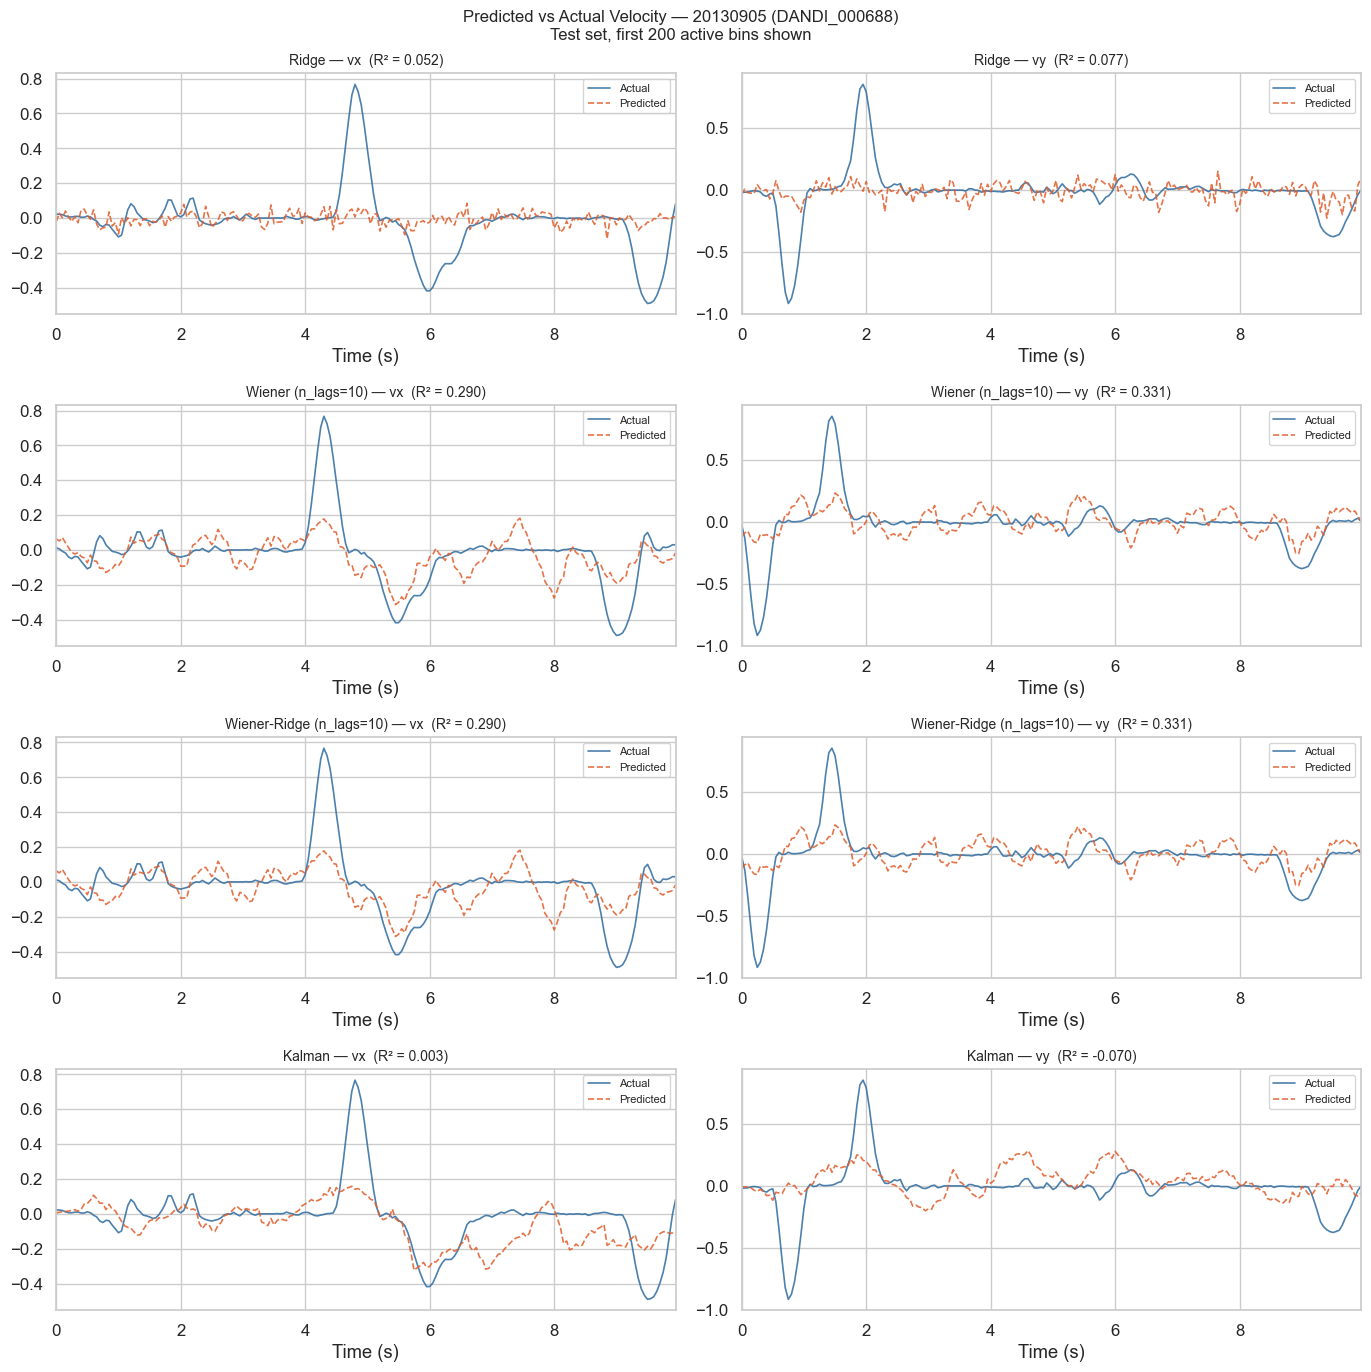

Saved: 01_ContinuousDecoding_DANDI688_velocity.png


In [15]:
pb_r = min(PLOT_BINS, len(y_test))
pb_w = min(PLOT_BINS, len(y_test_wiener))
pb_wr = min(PLOT_BINS, len(y_test_wiener_ridge))
pb_k = min(PLOT_BINS, len(y_test))
t_r  = np.arange(pb_r) * BIN_SIZE_MS / 1000
t_w  = np.arange(pb_w) * BIN_SIZE_MS / 1000
t_wr  = np.arange(pb_wr) * BIN_SIZE_MS / 1000
t_k  = np.arange(pb_k) * BIN_SIZE_MS / 1000

def _plot(ax, t, y_true, y_pred, r2_val, title):
    ax.plot(t, y_true, color="#2d6a9f", lw=1.2, label="Actual",    alpha=0.85)
    ax.plot(t, y_pred, color="#e05c2a", lw=1.2, label="Predicted", ls="--", alpha=0.85)
    ax.set_title(f"{title}  (R² = {r2_val:.3f})", fontsize=10)
    ax.set_xlabel("Time (s)")
    ax.legend(fontsize=8, loc="upper right")
    ax.set_xlim(t[0], t[-1])

fig, axes = plt.subplots(4, 2, figsize=(14, 14))
fig.suptitle(
    f"Predicted vs Actual Velocity — {session_id} (DANDI_000688)\n"
    f"Test set, first {PLOT_BINS} active bins shown",
    fontsize=12,
)

_plot(axes[0, 0], t_r, y_test[:pb_r, 0], y_pred_ridge[:pb_r, 0],   r2_ridge[0],  "Ridge — vx")
_plot(axes[0, 1], t_r, y_test[:pb_r, 1], y_pred_ridge[:pb_r, 1],   r2_ridge[1],  "Ridge — vy")
_plot(axes[1, 0], t_w, y_test_wiener[:pb_w, 0], y_pred_wiener[:pb_w, 0], r2_wiener[0], f"Wiener (n_lags={N_LAGS}) — vx")
_plot(axes[1, 1], t_w, y_test_wiener[:pb_w, 1], y_pred_wiener[:pb_w, 1], r2_wiener[1], f"Wiener (n_lags={N_LAGS}) — vy")
_plot(axes[2, 0], t_wr, y_test_wiener_ridge[:pb_wr, 0], y_pred_wiener_ridge[:pb_wr, 0], r2_wiener_ridge[0], f"Wiener-Ridge (n_lags={N_LAGS}) — vx")
_plot(axes[2, 1], t_wr, y_test_wiener_ridge[:pb_wr, 1], y_pred_wiener_ridge[:pb_wr, 1], r2_wiener_ridge[1], f"Wiener-Ridge (n_lags={N_LAGS}) — vy")
_plot(axes[3, 0], t_k, y_test[:pb_k, 0], y_pred_kalman[:pb_k, 0], r2_kalman[0], "Kalman — vx")
_plot(axes[3, 1], t_k, y_test[:pb_k, 1], y_pred_kalman[:pb_k, 1], r2_kalman[1], "Kalman — vy")

plt.tight_layout()
plt.savefig("01_ContinuousDecoding_DANDI688_velocity.png", dpi=120, bbox_inches="tight")
plt.show()
print("Saved: 01_ContinuousDecoding_DANDI688_velocity.png")